In [104]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import re
import math
from IPython.display import display, HTML
import html

In [131]:
ROOT_DIR = r"D:\implementation\p2psta\implementation\results"  
RUN_NAME = 'run_20250924_172554'

def pick_run(root_dir: str, run_name: str | None = None) -> Path | None:
    root = Path(root_dir)
    if run_name:
        rd = root / run_name
        return rd if rd.exists() else None
    runs = sorted(
        [p for p in root.glob("run_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return runs[0] if runs else None

RUN_DIR = pick_run(ROOT_DIR, RUN_NAME)
print("Using RUN_DIR:", RUN_DIR)
if RUN_DIR is None:
    raise FileNotFoundError("No run_* folder found. ")

Using RUN_DIR: D:\implementation\p2psta\implementation\results\run_20250924_172554


### Parameters and Timings Explanation

- **[Global Config]**
  - `data.csv_path`: Path to the dataset file used for ingestion.
  - `data.max_ingest`: Maximum number of records to ingest (`None` means all records).

- **[SFC Config]**
  - `algorithm`: Space-filling curve used (`z3` = 3D Z-order).
  - `center_lat`: Reference latitude for distance-to-meter conversion.
  - `x_precision_m`, `y_precision_m`: Spatial resolution in meters for X (longitude) and Y (latitude).
  - `t_precision_s`: Temporal resolution in seconds.
  - `derived_bits`: Bit lengths (`lx`, `ly`, `lt`) used for encoding; `ring_m` is the total key length for the DHT ring.
  - `global_lat`, `global_lon`, `global_time`: Bounding box of the dataset in latitude, longitude, and time.

- **[Experiment Config]**
  - `stop_tail_bits`: Controls granularity of range decomposition; smaller values = finer ranges.
  - `merge_gap_keys`: Threshold for merging small gaps between ranges (to reduce fragmentation).
  - `max_ranges`: Maximum number of ranges allowed per query (`None` = unlimited).

- **[Metrics]**
  - `precise_hits`: Whether precise post-filtering of results is enabled.
  - `save_with_nodes`: Whether query results are saved with node-level details.

- **[Queries]**
  - Total number of queries run in the experiment.
  - Each query includes: name, spatial bounding box (`lat`, `lon`), and temporal window (`time`).

- **Timings**
  - `ingest_ms`: Time spent ingesting all data (milliseconds).
  - `query[<name>]_ms`: Execution time of each query in milliseconds.


In [106]:
params_path = Path(RUN_DIR) / "params.txt"
with open(params_path, "r", encoding="utf-8") as f:
    params_text = f.read()
print(params_text)



[Global Config]
data.csv_path=geolife_clean.csv
data.max_ingest=None

[SFC Config]
algorithm=z3
center_lat=39.9
time_bucket_s=None
max_ranges=None
max_depth=Some(24)
max_nodes=Some(50000)
tail_bits_guard=None

[Network Config]
num_nodes=1024

[Placement Config]
mode=vnode
vnodes_per_node=100
derived_bits: lx=10 ly=10 lt=10 ring_m=30
global_lat=[39, 41] global_lon=[115, 118] global_time=[1176268800, 1343433600]

[Experiment Config]
stop_tail_bits=6
print_first=Some(15)
debug=Some(false)
prefix_bits=None

[Metrics]
precise_hits=Some(true)
save_with_nodes=Some(true)

[Queries] total=3
Q00: name=Some("forbidden_city"), lat=[39.906,39.923], lon=[116.386,116.411], time=[2008-08-01T03:00:00Z,2008-08-10T03:15:00Z]
Q01: name=Some("Guomao_CBD"), lat=[39.906,39.923], lon=[116.44,116.48], time=[2008-08-01T03:00:00Z,2008-08-10T03:15:00Z]
Q02: name=Some("Changping_District"), lat=[40.08,40.15], lon=[116.22,116.3], time=[2008-08-01T03:00:00Z,2008-08-10T03:15:00Z]



In [107]:
timings_path = Path(RUN_DIR) / "timings.txt"
with open(timings_path, "r", encoding="utf-8") as f:
    timings_text = f.read()
print(timings_text)

ingest_ms=17854
query[forbidden_city]_ms=112
query[Guomao_CBD]_ms=167
query[Changping_District]_ms=505



### About node_distribution.csv
This file summarizes how data is distributed across nodes in the DHT ring.

- **pnode_idx**: Index of the pnode in the experiment (0-based).  
- **vnode_id**: Identifier of the vnode on the DHT ring.  
- **total_count**: Number of records stored on this node.  
- **min_key**: Smallest key value stored on this node.  
- **max_key**: Largest key value stored on this node.  
- **key_span** (derived): The difference between `max_key` and `min_key`, indicating the portion of key space covered by the node.

In [108]:
csv_path = Path(RUN_DIR) / "node_distribution.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_distribution.csv not found at: {csv_path}")

# 读取 CSV；把空白当作缺失值处理
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64","vnode_idx": "Int64", "vnode_id": "Int64", "total_count": "Int64"},
    na_values=["", " ", "NA", "NaN"]
)

# 确保 min_key / max_key 为可空整型；缺失保持 NaN
for col in ["min_key", "max_key"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 计算 key_span（max_key - min_key）；缺失用 0
df["key_span"] = (df["max_key"] - df["min_key"]).astype("Int64")
df["key_span"] = df["key_span"].fillna(0)


df.head() 




,pnode_idx,vnode_idx,vnode_id,total_count,min_key,max_key,key_span
0,0,0,0,0,<NA>,<NA>,0
1,0,1024,10736640,0,<NA>,<NA>,0
2,0,2048,21473280,0,<NA>,<NA>,0
3,0,3072,32209920,0,<NA>,<NA>,0
4,0,4096,42946560,0,<NA>,<NA>,0


### Figure 1.1: Records per vnode
This chart shows the total number of records (`total_count`) stored on each node.  
- **X-axis:** Node index (`vnode_idx`)  
- **Y-axis:** Number of records stored  
The purpose of this figure is to reveal how evenly the data records are distributed across nodes. A balanced distribution indicates good load balancing, while large differences suggest potential hotspots.


In [109]:
summary_stats_vnode = {
    "total_count": {
        "mean": df["total_count"].mean(),
        "sum": df["total_count"].sum(),
        "std": df["total_count"].std(),
        'min': df['total_count'].min(),
        'max': df['total_count'].max(),
    },
    "key_span": {
        "mean": df["key_span"].mean(),
        "sum": df["key_span"].sum(),
        "std": df["key_span"].std(),
        'min': df['key_span'].min(),
        'max': df['key_span'].max(),
    }
}
summary_stats_vnode_df = pd.DataFrame(summary_stats_vnode)
display(HTML(summary_stats_vnode_df.to_html(float_format=lambda x: f"{x:,.4f}")))




,total_count,key_span
mean,191.7211,282.9569
sum,"19,632,236.0000","28,974,784.0000"
std,"4,853.2927","1,399.1379"
min,0.0000,0.0000
max,"718,707.0000","10,496.0000"


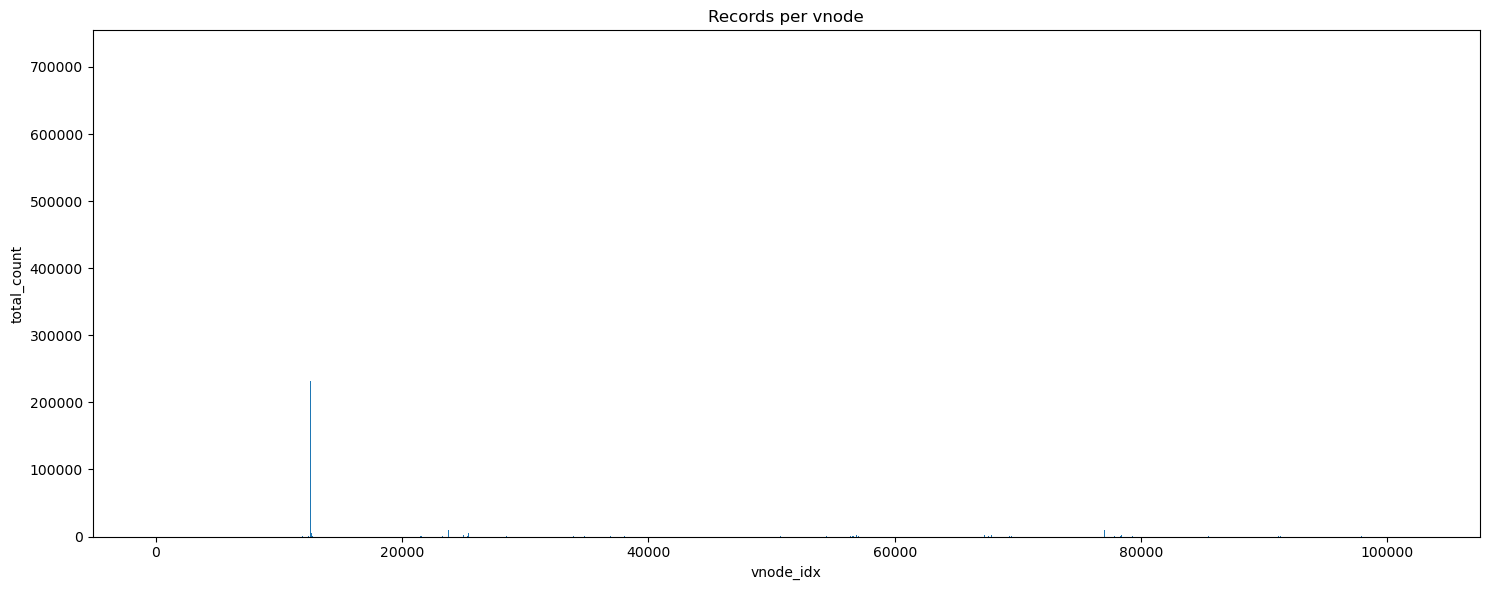

In [103]:
# --- 图1：每个 vnode 的 total_count ---
plt.figure(figsize=(15, 6))
plt.bar(df["vnode_idx"].fillna(0).astype(int), df["total_count"].fillna(0).astype(int))
plt.xlabel("vnode_idx")
plt.ylabel("total_count")
plt.title("Records per vnode")
plt.tight_layout()
plt.show()


### Figure 1.2: Records per pnode
This chart shows the total number of records (`total_count`) stored on each node.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Number of records stored  
The purpose of this figure is to reveal how evenly the data records are distributed across nodes. A balanced distribution indicates good load balancing, while large differences suggest potential hotspots.


In [110]:
# 去掉 vnode_id 列
pnode_df = df.drop(columns=["vnode_id"])

# 对每个 pnode 计算常见聚合（你可按需增减）
pnode_agg = pnode_df.groupby("pnode_idx").agg(
    vnode_count=("total_count", "count"),          # 该 pnode 下的 vnode 数
    total_count=("total_count", "sum"),
    key_span=("key_span", "sum"),
    min_key=("min_key", "min"),
    max_key=("max_key", "max")
).reset_index()

pnode_agg.head()


,pnode_idx,vnode_count,total_count,key_span,min_key,max_key
0,0,100,1850,29824,64414464,858925696
1,1,100,16995,35264,118105600,654945472
2,2,100,12608,15360,64434816,826741376
3,3,100,1287,8896,21504512,826744704
4,4,100,1716,12160,21504768,912656064


In [112]:
summary_stats_pnode = {
    "total_count": {
        "mean": pnode_agg["total_count"].mean(),
        "sum": pnode_agg["total_count"].sum(),
        "std": pnode_agg["total_count"].std(),
        'min': pnode_agg['total_count'].min(),
        'max': pnode_agg['total_count'].max(),  
    },
    "key_span": {
        "mean": pnode_agg["key_span"].mean(),
        "sum": pnode_agg["key_span"].sum(),
        "std": pnode_agg["key_span"].std(),
        'min': pnode_agg['key_span'].min(),
        'max': pnode_agg['key_span'].max(),
    }
}
summary_stats_pnode_df = pd.DataFrame(summary_stats_pnode)
display(HTML(summary_stats_pnode_df.to_html(float_format=lambda x: f"{x:,.4f}")))

,total_count,key_span
mean,"19,172.1055","28,295.6875"
sum,"19,632,236.0000","28,974,784.0000"
std,"46,826.9112","10,991.6901"
min,26.0000,"1,984.0000"
max,"721,566.0000","66,624.0000"


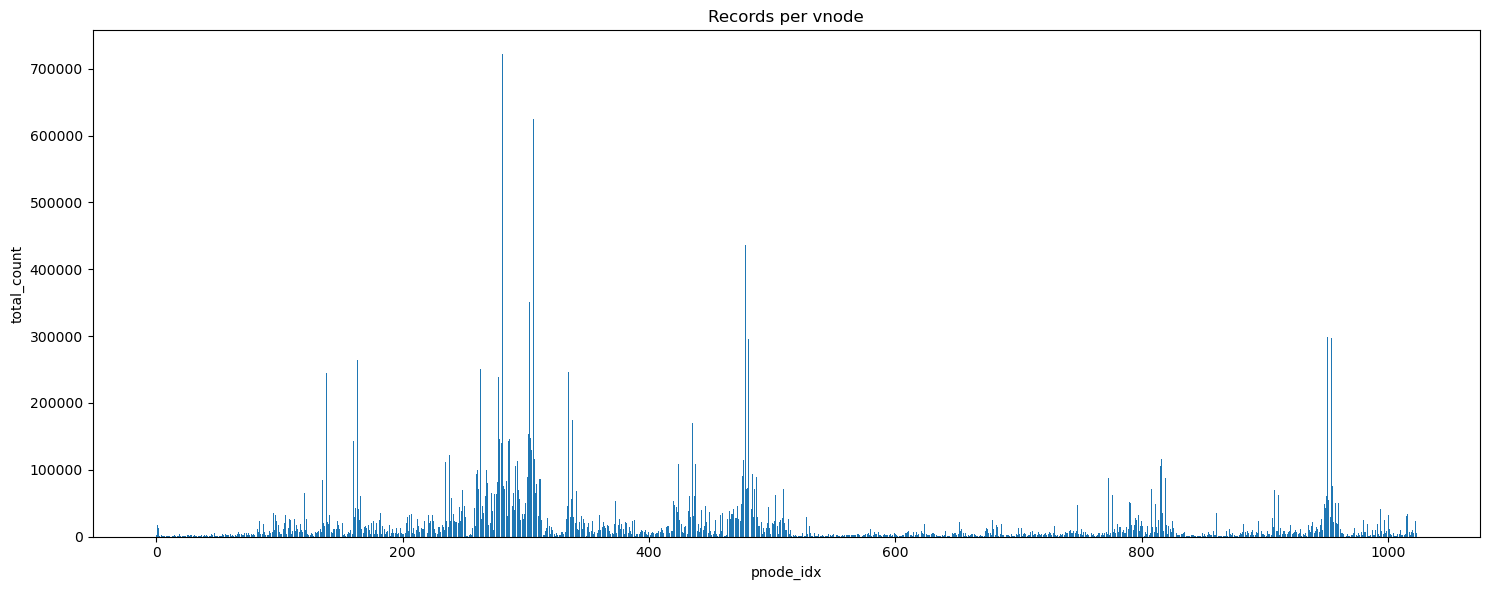

In [ ]:
# --- 图1：每个 pnode 的 total_count ---
plt.figure(figsize=(15, 6))
plt.bar(pnode_agg["pnode_idx"].fillna(0).astype(int), pnode_agg["total_count"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("total_count")
plt.title("Records per pnode")
plt.tight_layout()
plt.show()

### Figure 2: Key span per pnode
This chart illustrates the key range assigned to each node, computed as `max_key - min_key`.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Key span size  
This figure highlights how the key space is partitioned among the nodes. Large variations in span size imply that some nodes cover significantly larger portions of the key space, which may affect query routing and balance.


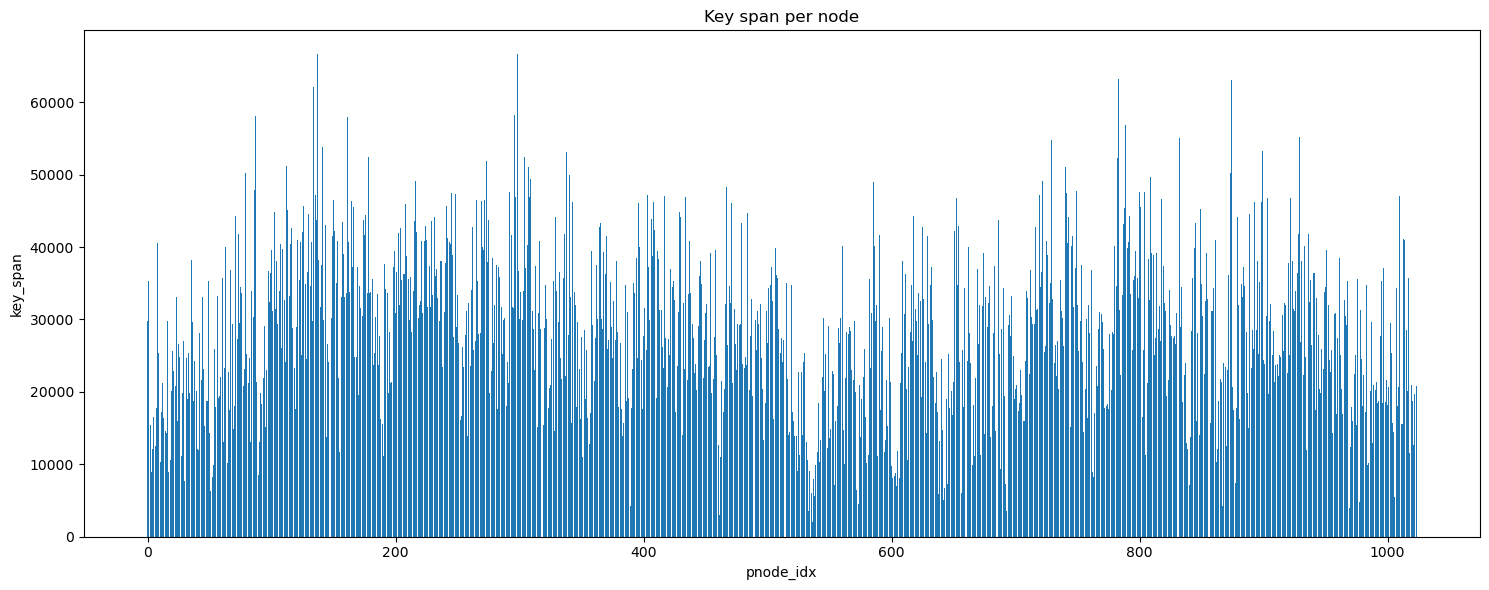

In [114]:
# --- 图2：每个 node 的 key_span（max_key - min_key）---
plt.figure(figsize=(15, 6))
plt.bar(pnode_agg["pnode_idx"].fillna(0).astype(int), pnode_agg["key_span"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("key_span")
plt.title("Key span per node")
plt.tight_layout()
plt.show()

### About node_ranges.csv
This file describes each node's responsibility interval on the key ring and the data actually stored within that interval.

- **pnode_idx**: Index of the node in the experiment (0-based).
- **node_id**: Identifier of the node on the DHT ring.
- **resp_start**: Start of the responsibility interval on the ring (in key space).
- **resp_end**: End of the responsibility interval on the ring (in key space).
- **wrapped**: Whether the interval wraps around the zero point of the ring (if `true`, the interval is split across the end and the beginning of the ring).
- **stored_total**: Number of records actually stored on this node.
- **stored_min**: Minimum key of stored records on this node (if any).
- **stored_max**: Maximum key of stored records on this node (if any).

> Note: The ring size is `2^ring_m`, where `ring_m` is read from `params.txt`. The effective interval length is computed modulo the ring size.


In [116]:
csv_path = Path(RUN_DIR) / "node_ranges.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_ranges.csv not found at: {csv_path}")

df = pd.read_csv(
    csv_path,
    dtype={
        "pnode_idx": "Int64",
        "vnode_idx": "Int64",
        "vnode_id": "Int64",
        "resp_start": "Int64",
        "resp_end": "Int64",
        "stored_total": "Int64",
        "stored_min": "Int64",
        "stored_max": "Int64",
    },
    na_values=["", " ", "NA", "NaN"]
)

# 规范 wrapped 布尔列
if "wrapped" in df.columns:
    df["wrapped"] = df["wrapped"].astype(str).str.lower().map({"true": True, "false": False})
else:
    df["wrapped"] = False

# ---- 解析 ring_m（来自 params.txt），计算环长 ----
params_path = Path(RUN_DIR) / "params.txt"
if not params_path.exists():
    raise FileNotFoundError(f"params.txt not found at: {params_path} (needed to parse ring_m)")

params_text = params_path.read_text(encoding="utf-8", errors="ignore")
m = re.search(r"ring_m\s*=\s*(\d+)", params_text)
if not m:
    raise ValueError("Unable to parse ring_m from params.txt (expected like 'ring_m=39').")
ring_m = int(m.group(1))
ring_size = 1 << ring_m

print(f"ring_m = {ring_m}, ring_size = {ring_size}")

# ---- 计算责任跨度（模环长）----
# exclusive 跨度： (end - start) mod ring_size
resp_span_excl = (df["resp_end"].astype("Int64") - df["resp_start"].astype("Int64")) % ring_size
df["resp_span"] = resp_span_excl.astype("Int64")
# 也可以给出 inclusive 的跨度（+1），但作图用 resp_span 更直观
df["resp_span_inclusive"] = (df["resp_span"] + 1).astype("Int64")

# 存储区间跨度（若存在）
df["stored_span"] = (df["stored_max"] - df["stored_min"]).astype("Int64")
df["stored_span"] = df["stored_span"].fillna(0)

# 排序（按 pnode_idx）
df = df.sort_values("pnode_idx").reset_index(drop=True)
df.head()

ring_m = 30, ring_size = 1073741824


,pnode_idx,vnode_idx,vnode_id,resp_start,resp_end,wrapped,stored_total,stored_min,stored_max,resp_span,resp_span_inclusive,stored_span
0,0,0,0,1073653516,0,True,0,<NA>,<NA>,88308,88309,0
1,0,73728,773038080,773027596,773038080,False,0,<NA>,<NA>,10484,10485,0
2,0,72704,762301440,762290956,762301440,False,0,<NA>,<NA>,10484,10485,0
3,0,71680,751564800,751554316,751564800,False,0,<NA>,<NA>,10484,10485,0
4,0,70656,740828160,740817676,740828160,False,0,<NA>,<NA>,10484,10485,0


In [121]:
# 去掉 vnode_id 列
pnode_df = df.drop(columns=["vnode_id"])

# 对每个 pnode 计算常见聚合（你可按需增减）
pnode_agg = pnode_df.groupby("pnode_idx").agg(
    resp_start=("resp_start", "min"),          # 该 pnode 下的 vnode 数
    resp_end=("resp_end", "max"),
    stored_total=("stored_total", "sum"),
    stored_min=("stored_min", "min"),
    stored_max=("stored_max", "max")
).reset_index()

resp_span_excl = (pnode_agg["resp_end"].astype("Int64") - pnode_agg["resp_start"].astype("Int64")) % ring_size
pnode_agg["resp_span"] = resp_span_excl.astype("Int64")
pnode_agg["stored_span"] = (pnode_agg["stored_max"] - pnode_agg["stored_min"]).astype("Int64")
pnode_agg["stored_span"] = pnode_agg["stored_span"].fillna(0)
pnode_agg.head()

,pnode_idx,resp_start,resp_end,stored_total,stored_min,stored_max,resp_span,stored_span
0,0,10726156,1062927360,1850,64414464,858925696,1052201204,794511232
1,1,1,1062937845,16995,118105600,654945472,1062937844,536839872
2,2,10486,1062948330,12608,64434816,826741376,1062937844,762306560
3,3,20971,1062958815,1287,21504512,826744704,1062937844,805240192
4,4,31456,1062969300,1716,21504768,912656064,1062937844,891151296


### Figure 1: stored span per pnode
This bar chart shows the size of each pnode's stored interval on the ring, computed as `(stored_end - stored_start) mod ring_size`.
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** stored span (in key counts)
If some nodes cover much larger spans than others, the ring partitioning may be uneven, which can affect routing and load balance.


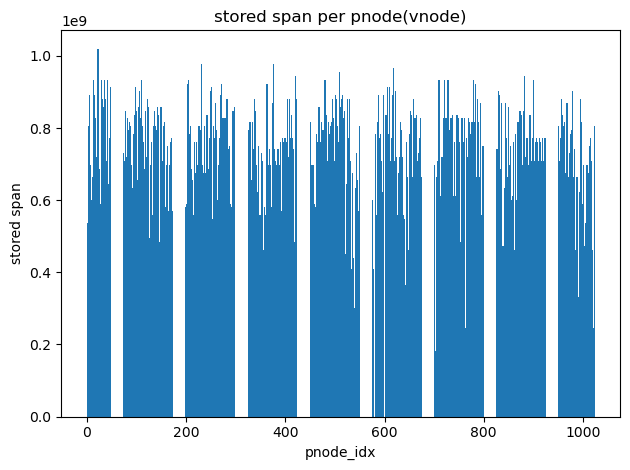

In [125]:
plt.figure()
plt.bar(pnode_agg["pnode_idx"].astype(int), pnode_agg["stored_span"].astype("Int64").fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("stored span")
plt.title("stored span per pnode(vnode)")
plt.tight_layout()
plt.show()

#### Query results of project

In [132]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}

files = {
    name: qdir / "query_results.csv"
    for name, qdir in queries.items()
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path,
        parse_dates=['datetime'],
        dtype={'traj_id': str}
    )
    df['traj_id'] = df['traj_id'].str.strip()

    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'rows': len(df),
        'users': df['user'].nunique(),
        'trajs': df['traj_id'].nunique(),
        'first': df['datetime'].min(),
        'last': df['datetime'].max()
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")


=== forbidden_city ===
rows : 62
users: 1
trajs: 1
time : 2008-08-03 20:49:28+00:00  ~  2008-08-04 07:55:16+00:00

=== Guomao_CBD ===
rows : 1454
users: 2
trajs: 7
time : 2008-08-01 20:02:13+00:00  ~  2008-08-06 19:03:12+00:00

=== Changping_District ===
rows : 344
users: 1
trajs: 3
time : 2008-08-01 03:30:37+00:00  ~  2008-08-08 14:40:20+00:00


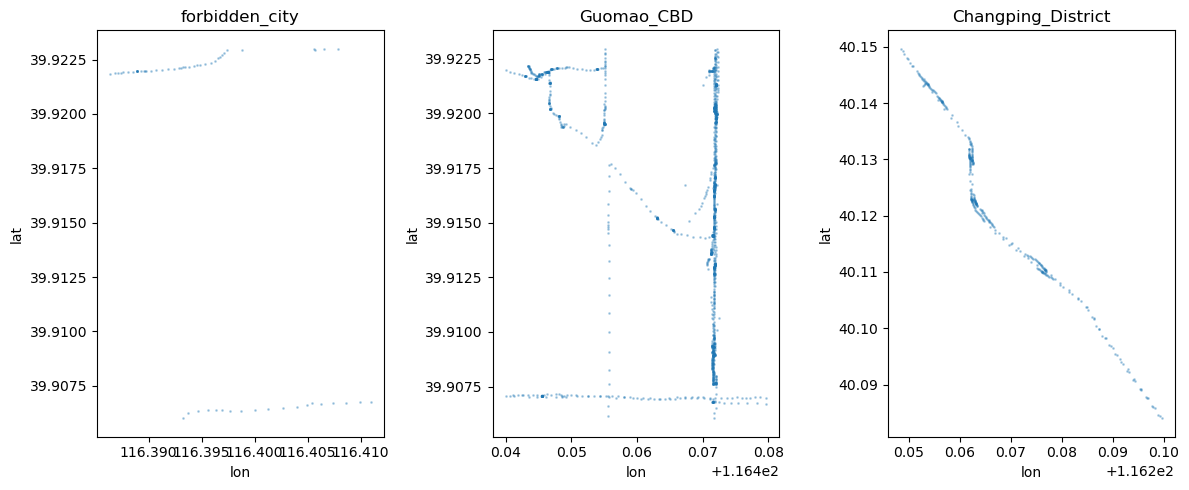

In [133]:
n_query = len(queries)
fig, axes = plt.subplots(1, n_query, figsize=(12, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        ax.set_title(f'{name} no data')
        continue
    plot_df = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(plot_df.lon, plot_df.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

In [134]:

queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}
MAX_PREVIEW_LINES = 60  # 预览显示的行数，可按需调整

def read_text_file(path: Path) -> str:
    if not path.exists():
        return f"[MISSING] {path}"
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return path.read_text(encoding=enc, errors="replace")
        except Exception:
            continue
    return f"[ERROR] Failed to read {path}"

def show_collapsible(title: str, text: str, max_preview_lines: int = 60):
    lines = text.splitlines()
    preview = "\n".join(lines[:max_preview_lines])
    more = max(0, len(lines) - max_preview_lines)

    esc_title = html.escape(title)
    esc_preview = html.escape(preview)
    esc_full = html.escape(text)

    html_block = f"""
    <div style='margin:0.75rem 0;'>
      <div style='font-weight:700; margin-bottom:4px;'>{esc_title}</div>
      <div style='border:1px solid #ddd; border-radius:6px; padding:8px;'>
        <div style='max-height:280px; overflow:auto; white-space:pre; font-family:monospace;'>{esc_preview}</div>
        {'<div style="color:#888; font-style:italic; margin-top:4px;">… ' + str(more) + ' more lines</div>' if more>0 else ''}
        <details style='margin-top:6px;'>
          <summary>Show full</summary>
          <div style='max-height:420px; overflow:auto; white-space:pre; font-family:monospace; margin-top:6px;'>{esc_full}</div>
        </details>
      </div>
    </div>
    """
    display(HTML(html_block))

for name, qdir in queries.items():
    display(HTML(f"<h3 style='margin-top:1.25rem'>QUERY: {html.escape(name)}</h3>"))

    win_path = qdir / "window.txt"
    sum_path = qdir / "summary.txt"

    win_txt = read_text_file(win_path)
    sum_txt = read_text_file(sum_path)

    show_collapsible(f"window.txt — {win_path}", win_txt, MAX_PREVIEW_LINES)
    show_collapsible(f"summary.txt — {sum_path}", sum_txt, MAX_PREVIEW_LINES)


In [135]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "Guomao_CBD":         Path(RUN_DIR) / "query_01_Guomao_CBD",
    'Changping_District': Path(RUN_DIR) / "query_02_Changping_District",
}
files = {name: qdir / "pnode_report.csv" for name, qdir in queries.items()}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path
    )
    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'total_pnodes': df['pnode_idx'].nunique(),
        'total_count': df['returned_count'].sum(),
        'total_hops': df['route_hops'].sum(),
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"total pnodes: {s['total_pnodes']}")
    print(f"total count : {s['total_count']}")
    print(f"total hops  : {s['total_hops']}")
    print(f"avg hops/pnode: {s['total_hops'] / s['total_pnodes'] if s['total_pnodes'] > 0 else 0:.4f}")
    print(f"avg count/pnode: {s['total_count'] / s['total_pnodes'] if s['total_pnodes'] > 0 else 0:.4f}")
    print(f"avg count/hop : {s['total_count'] / s['total_hops'] if s['total_hops'] > 0 else 0:.4f}")    



=== forbidden_city ===
total pnodes: 9
total count : 62
total hops  : 93
avg hops/pnode: 10.3333
avg count/pnode: 6.8889
avg count/hop : 0.6667

=== Guomao_CBD ===
total pnodes: 7
total count : 1454
total hops  : 68
avg hops/pnode: 9.7143
avg count/pnode: 207.7143
avg count/hop : 21.3824

=== Changping_District ===
total pnodes: 10
total count : 344
total hops  : 81
avg hops/pnode: 8.1000
avg count/pnode: 34.4000
avg count/hop : 4.2469
